In [50]:
import numpy as np
from tensorflow import keras, config
from keras.layers import InputLayer, Dense, MaxPool1D, Conv1D
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
import time

In [51]:
#Загрузка с диска 
allMnist = np.load('mnist.npy', allow_pickle=True)
x_train, y_train, x_test, y_test = allMnist[0], allMnist[1],allMnist[2],allMnist[3]

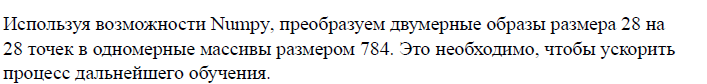

In [52]:
# преобразуем двумерные данные в одномерные 
x_train = x_train.reshape(x_train.shape[0], 784)
x_test = x_test.reshape(x_test.shape[0], 784)

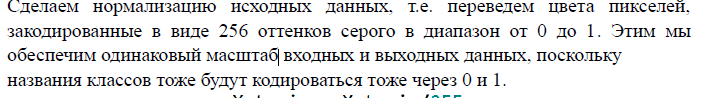

In [53]:
x_train = x_train/255
x_test = x_test/255

Преобразуем целевые значения методом «one-hot encoding», т.е. преобразуем их в унитарный код. В результате, например, классу цифры 5 будет соответствовать выходной вектор [0 0 0 0 0 1 0 0 0 0], где слева нулевая позиция, а справа 9я позиция. Иначе говоря, здесь мы сразу ориентируемся на структуру выходного
слоя, где каждому классу будет соответствовать свой нейрон, выдающий степень принадлежности образа к данному классу.

In [63]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10) 

In [55]:
# Список всех доступных физических устройств
print("Доступные устройства:", config.list_physical_devices())

# Проверка наличия GPU
gpus = config.list_physical_devices('GPU')
if gpus:
    print(f" GPU найден: {gpus}")
else:
    print(" GPU не найден, обучение будет на CPU")

Доступные устройства: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
 GPU не найден, обучение будет на CPU


In [56]:
model = keras.models.Sequential([
    InputLayer(shape=(784,)),      # Вход: 784 признака
    Dense(784, activation='relu'),       # Скрытый слой
    Dense(256, activation='relu'),       # Скрытый слой (опционально)
    Dense(10, activation='softmax')      # ВЫХОД: 10 классов (0-9)
])


In [57]:
model.compile(loss='binary_crossentropy',
              optimizer = Adam(learning_rate=0.0001),
              metrics = ['binary_accuracy'])

In [58]:
stop = EarlyStopping(monitor='val_binary_accuracy', verbose=1, patience=100, restore_best_weights=True)

In [59]:
start = time.time()
model.fit(x_train, y_train, epochs=100, batch_size=500, validation_split=0.2, callbacks=[stop])
end = time.time() - start

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - binary_accuracy: 0.9169 - loss: 0.3022 - val_binary_accuracy: 0.9633 - val_loss: 0.1448
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9731 - loss: 0.1103 - val_binary_accuracy: 0.9811 - val_loss: 0.0816
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9813 - loss: 0.0756 - val_binary_accuracy: 0.9843 - val_loss: 0.0637
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9841 - loss: 0.0615 - val_binary_accuracy: 0.9861 - val_loss: 0.0538
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - binary_accuracy: 0.9861 - loss: 0.0527 - val_binary_accuracy: 0.9877 - val_loss: 0.0474
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9876 - loss: 0.0466 - val_binary_accuracy: 0.9888 - val_loss: 0.0428
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9887 - loss: 0.0419 - val_binary_accuracy: 0.9898 - val_loss: 0.0391
Epoch 

In [60]:
X = np.concatenate([x_train,x_test])
Y = np.concatenate([allMnist[1], allMnist[3]])

In [61]:
ans = model.predict(X, verbose=0)
ans = np.round(ans).astype(int)
ans = np.argmax(ans, axis=-1)
comp = Y == ans
print('Процент ошибок по всем образцам: ', np.count_nonzero (comp == False)/len(Y))
if input('Сохранить модель [y/n]?: ')=='y':
    model.save('mnistALL.keras')

Процент ошибок по всем образцам:  0.005871428571428572


In [64]:
# Оценка
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Точность: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9965 - loss: 0.0154
Точность: 0.9965
